In [20]:
## Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [35]:
## Load Data
data = pd.read_csv("/Users/benleon/Physics Projs/Phys 20CL/data/franck_hertz_data.csv")

## Define Variables -- Collector Current I, Accelerating Voltage V, Retarding Voltage V_r
I = data["I (nA)"]
V = data["Va (V)"]
V_r = 1.3

## Uncertainty in each variable
dV = 0.005 # V
dI = 0.005 # nA

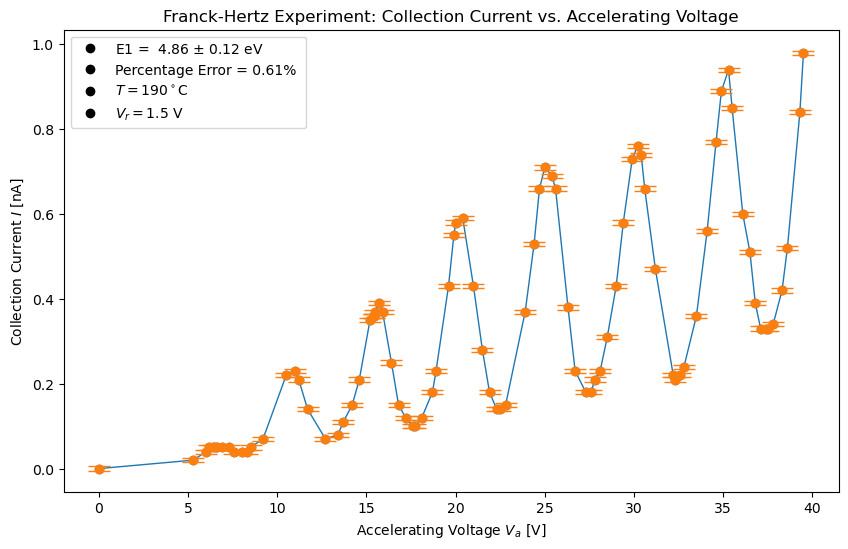

In [98]:
## Find indices Local Maximum and Minimum Voltages
peaks, properties = find_peaks(I, prominence=0.05, distance=5)
V_peaks = V[peaks]

## Calculate Average First Excitation Energy
differences = np.diff(V_peaks)
avg_first_e = np.mean(differences)
std_first_e = np.std(differences, ddof = 1) / np.sqrt(len(differences))

## Percentage Error Compared to Spectroscopically Measured Value 
pc_error = np.abs((avg_first_e - 4.89)/ 4.89) * 100


## Plot 
plt.figure(figsize= (10, 6))
plt.plot(V, I, linewidth = 1)
plt.errorbar(V, I, yerr = dI, fmt = 'o', capsize = 8)
plt.scatter(V, I)
plt.ylabel("Collection Current $I$ [nA]")
plt.xlabel("Accelerating Voltage $V_a$ [V]")
plt.title("Franck-Hertz Experiment: Collection Current vs. Accelerating Voltage")
plt.plot([], [], label = f"E1 =  {avg_first_e:.2f} $\pm$ {std_first_e:.2f} eV ", marker = 'o', linestyle = 'none', color = 'black')
plt.plot([], [], label = f"Percentage Error = {pc_error:.2f}% ", marker = 'o', linestyle = 'none', color = 'black')
plt.plot([], [], label = r"$T = 190^\circ\mathrm{C}$ ", marker = 'o', linestyle = 'none', color = 'black')
plt.plot([], [], label = r"$V_r = 1.5\ \mathrm{V}$ ", marker = 'o', linestyle = 'none', color = 'black')
plt.legend()
plt.savefig("/Users/benleon/Physics Projs/Phys 20CL/plots/franck_hertz_plot.png")
plt.plot()
plt.show()


